In [1]:
import os, sys, types
os.environ["DDE_BACKEND"] = "pytorch"
from pathlib import Path
from typing import Tuple, Dict
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO = Path("/scratch/mbarajas/epi-rl")
os.chdir(REPO)

from pinn_seir.config import ModelConfig, TrainConfig
from pinn_seir.data import load_epi_data
from pinn_seir.model import PINNTrainer
from pinn_seir.physics import beta_per_patch, seir_residuals

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_TRAINING = False

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
mcfg = ModelConfig(flu_path=Path("data/epidemic/uk_flu_per_100000.csv"))
data = load_epi_data(mcfg)
P = data.n_patches
N_WEEKS = mcfg.n_weeks

In [3]:
def load_net(ckpt):
    tcfg = TrainConfig(dropout_rate=0.1, device=DEVICE)
    trainer = PINNTrainer(data, mcfg, tcfg)
    trainer.load_checkpoint(ckpt)
    trainer.net.eval()
    return trainer

In [4]:
FRACTIONS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def closure_sweep(trainer, week=20):
    net, dev = trainer.net, trainer.device
    week_t = torch.tensor([week], dtype=torch.int64, device=dev)
    tau = torch.full((1, 1), 0.5, device=dev)
    out = []
    for f in FRACTIONS:
        c = torch.ones((1, P), device=dev)
        c[0, :int(round(f * P))] = 0.0
        with torch.no_grad():
            s = net(tau, week_t, c)
        out.append((f, s[..., 0].sum().item(), s[..., 2].sum().item()))
    return out

def s_range_0_90(sweep):
    S = [s for _, s, _ in sweep[:-1]]
    return max(S) - min(S)

def full_season(trainer, tau_val=0.99):
    net, dev = trainer.net, trainer.device
    out = []
    for wk in range(N_WEEKS):
        week_t = torch.tensor([wk], dtype=torch.int64, device=dev)
        tau = torch.full((1, 1), tau_val, device=dev)
        c = torch.ones((1, P), device=dev)
        with torch.no_grad():
            s = net(tau, week_t, c)
        out.append((wk, s[..., 0].sum().item(), s[..., 4].sum().item()))
    return out

def within_week(trainer, week=20):
    net, dev = trainer.net, trainer.device
    out = []
    for tv in [0.0, 0.5, 0.99]:
        week_t = torch.tensor([week], dtype=torch.int64, device=dev)
        tau = torch.full((1, 1), tv, device=dev)
        c = torch.ones((1, P), device=dev)
        with torch.no_grad():
            s = net(tau, week_t, c)
        out.append((tv, s[..., 0].sum().item(), s[..., 4].sum().item()))
    return out

In [5]:
CKPT_BASELINE = "outputs/seir_pinn/11426009/checkpoint.pt"
CKPT_FIX1 = "outputs/seir_pinn/trillium_fixed_run/checkpoint_iter020000.pt"
CKPT_ATTEMPT1_SELFREF = "outputs/seir_pinn/trillium_activity_weight_test/checkpoint_iter005000.pt"
CKPT_ATTEMPT2_DATAPRIOR = "outputs/seir_pinn/trillium_activity_weight_v2/checkpoint_iter005000.pt"
CKPT_ATTEMPT3_MONO_CUM = "outputs/seir_pinn/trillium_mono_cumulative/checkpoint_iter005000.pt"

In [6]:
FIX1_CONFIG = dict(adam_iters=20000, dropout_rate=0.1, n_schedules=32, n_collocation=64,
                   w_phys=100, w_monotonic=0.0, w_cumulative=0.0, phys_activity_floor=1e9,
                   device=DEVICE)
if RUN_TRAINING:
    tr = PINNTrainer(data, mcfg, TrainConfig(**FIX1_CONFIG))
    tr.train(checkpoint_dir="outputs/seir_pinn/trillium_fixed_run", checkpoint_every=5000)

In [7]:
fix1 = load_net(CKPT_FIX1)
print("R0", fix1.r0.item())
print("S range 0-90%:", f"{s_range_0_90(closure_sweep(fix1)):,.0f}")

R0 1.7462189197540283
S range 0-90%: 550,660


In [8]:
def loss_physics_attempt1_selfreferential_DISCARDED(self, schedules):
    Ns, n_weeks, Ppatch = schedules.shape
    nc = self.tcfg.n_collocation
    beta_p = beta_per_patch(self.consts, self.r0)
    total = torch.zeros((), device=self.device, dtype=self.dtype)
    for s in range(Ns):
        tau = torch.rand(n_weeks * nc, 1, device=self.device, dtype=self.dtype)
        weeks = torch.repeat_interleave(torch.arange(n_weeks, device=self.device), nc)
        policy = schedules[s][weeks]
        state, dstate = self._time_derivative(tau, weeks, policy)
        effective_open = self._term_time(tau, weeks) * policy
        res = seir_residuals(self.consts, state, dstate, beta_p, self.mu, self.kappa, effective_open)
        infectious = (state[..., 2] + state[..., 3]).detach()
        activity = infectious.mean(dim=(1, 2))
        weight = (activity / (activity.mean() + 1e-8)).view(-1, 1, 1, 1)
        total = total + (weight * res ** 2).mean()
    return total / Ns, torch.zeros((), device=self.device, dtype=self.dtype)

In [9]:
ATTEMPT1_CONFIG = dict(adam_iters=5000, dropout_rate=0.1, n_schedules=16, n_collocation=32,
                       w_phys=100, w_monotonic=0.0, w_cumulative=0.0, phys_activity_floor=0.1,
                       device=DEVICE)
if RUN_TRAINING:
    tr = PINNTrainer(data, mcfg, TrainConfig(**ATTEMPT1_CONFIG))
    tr.loss_physics = types.MethodType(loss_physics_attempt1_selfreferential_DISCARDED, tr)
    tr.train(checkpoint_dir="outputs/seir_pinn/trillium_activity_weight_test", checkpoint_every=1000)

In [10]:
attempt1 = load_net(CKPT_ATTEMPT1_SELFREF)
print("R0", attempt1.r0.item())
print("S range 0-90%:", f"{s_range_0_90(closure_sweep(attempt1)):,.0f}")

R0 1.6965997219085693
S range 0-90%: 16


In [11]:
def build_priors(self, data, mcfg):
    obs_per_week = np.zeros(mcfg.n_weeks, dtype=np.float64)
    obs_per_week[data.obs_week_index] = np.clip(data.y_obs.sum(axis=0), 0.0, None)
    peak = obs_per_week.max()
    obs_per_week = obs_per_week / peak if peak > 0 else obs_per_week
    self.week_activity_prior = T(obs_per_week)

    total_symptomatic = float(
        (data.y_obs.sum(axis=1) * data.nation_population).sum()
    ) / (mcfg.alpha_init * mcfg.observation_scale)
    total_infections = total_symptomatic / mcfg.f_sym
    self._target_cumulative_R = T(total_infections)
    self._last_obs_week = int(data.obs_week_index.max())

In [12]:
ATTEMPT2_CONFIG = dict(adam_iters=5000, dropout_rate=0.1, n_schedules=16, n_collocation=32,
                       w_phys=100, w_monotonic=0.0, w_cumulative=0.0, phys_activity_floor=0.1,
                       device=DEVICE)
if RUN_TRAINING:
    tr = PINNTrainer(data, mcfg, TrainConfig(**ATTEMPT2_CONFIG))
    tr.train(checkpoint_dir="outputs/seir_pinn/trillium_activity_weight_v2", checkpoint_every=1000)

In [13]:
attempt2 = load_net(CKPT_ATTEMPT2_DATAPRIOR)
print("R0", attempt2.r0.item())
print("S range 0-90%:", f"{s_range_0_90(closure_sweep(attempt2)):,.0f}")

R0 1.6816776990890503
S range 0-90%: 20,880


In [14]:
def loss_physics(self, schedules: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    Ns, n_weeks, P = schedules.shape
    A = self.mcfg.n_age_groups
    nc = self.tcfg.n_collocation

    beta_p = beta_per_patch(self.consts, self.r0)
    floor = self.tcfg.phys_activity_floor
    week_weight_table = self.week_activity_prior + floor
    week_weight_table = week_weight_table / week_weight_table.mean()
    total = torch.zeros((), device=self.device, dtype=self.dtype)
    total_mono = torch.zeros((), device=self.device, dtype=self.dtype)

    for s in range(Ns):
        tau = torch.rand(n_weeks * nc, 1, device=self.device, dtype=self.dtype)
        weeks = torch.repeat_interleave(
            torch.arange(n_weeks, device=self.device), nc
        )
        policy = schedules[s][weeks]
        state, dstate = self._time_derivative(tau, weeks, policy)
        term = self._term_time(tau, weeks)
        effective_open = term * policy
        res = seir_residuals(
            self.consts, state, dstate, beta_p, self.mu, self.kappa, effective_open
        )
        weight = week_weight_table[weeks].view(-1, 1, 1, 1)
        total = total + (weight * res ** 2).mean()

        N = self.consts.N.unsqueeze(0)
        dS_frac = dstate[..., 0] / N
        dR_frac = dstate[..., 4] / N
        mono = torch.relu(dS_frac).pow(2) + torch.relu(-dR_frac).pow(2)
        w2 = week_weight_table[weeks].view(-1, 1, 1)
        total_mono = total_mono + (w2 * mono).mean()
    return total / Ns, total_mono / Ns

In [15]:
def loss_cumulative(self) -> torch.Tensor:
    true_policy = torch.as_tensor(
        self.sampler.true, dtype=self.dtype, device=self.device
    )
    tau = torch.full((1, 1), 0.99, device=self.device, dtype=self.dtype)
    week_t = torch.tensor([self._last_obs_week], dtype=torch.int64, device=self.device)
    closure_t = true_policy[self._last_obs_week].unsqueeze(0)
    state = self.net(tau, week_t, closure_t)
    R_pred = state[..., 4].sum()
    target = self._target_cumulative_R
    return ((R_pred - target) / target.clamp_min(1.0)) ** 2

In [16]:
ATTEMPT3_CONFIG = dict(adam_iters=5000, dropout_rate=0.1, n_schedules=16, n_collocation=32,
                       w_phys=100, w_monotonic=10.0, w_cumulative=10.0, phys_activity_floor=0.1,
                       device=DEVICE)
if RUN_TRAINING:
    tr = PINNTrainer(data, mcfg, TrainConfig(**ATTEMPT3_CONFIG))
    tr.train(checkpoint_dir="outputs/seir_pinn/trillium_mono_cumulative", checkpoint_every=1000)

In [17]:
attempt3 = load_net(CKPT_ATTEMPT3_MONO_CUM)
print("R0", attempt3.r0.item())
print("S range 0-90%:", f"{s_range_0_90(closure_sweep(attempt3)):,.0f}")
for tv, S, R in within_week(attempt3, 20):
    print(f"tau={tv:.2f}  R={R:,.2f}")

R0 0.7183637022972107
S range 0-90%: 58,972
tau=0.00  R=3,426,500.50
tau=0.50  R=3,426,494.50
tau=0.99  R=3,426,488.50


In [18]:
runs = [
    ("baseline", CKPT_BASELINE),
    ("fix1_schedule_wphys", CKPT_FIX1),
    ("attempt1_selfref", CKPT_ATTEMPT1_SELFREF),
    ("attempt2_dataprior", CKPT_ATTEMPT2_DATAPRIOR),
    ("attempt3_mono_cum", CKPT_ATTEMPT3_MONO_CUM),
]
summary, sweeps, seasons = {}, {}, {}
for name, ckpt in runs:
    tr = load_net(ckpt)
    sweeps[name] = closure_sweep(tr)
    seasons[name] = full_season(tr)
    summary[name] = (s_range_0_90(sweeps[name]), tr.r0.item())
    del tr
    torch.cuda.empty_cache() if DEVICE == "cuda" else None

for name, (span, r0) in summary.items():
    print(f"{name:24s}  S_range_0_90={span:12,.0f}   R0={r0:.4f}")

Rebuilding network to match checkpoint architecture (5x128, embed=8).


baseline                  S_range_0_90=      41,260   R0=1.0127
fix1_schedule_wphys       S_range_0_90=     550,660   R0=1.7462
attempt1_selfref          S_range_0_90=          16   R0=1.6966
attempt2_dataprior        S_range_0_90=      20,880   R0=1.6817
attempt3_mono_cum         S_range_0_90=      58,972   R0=0.7184


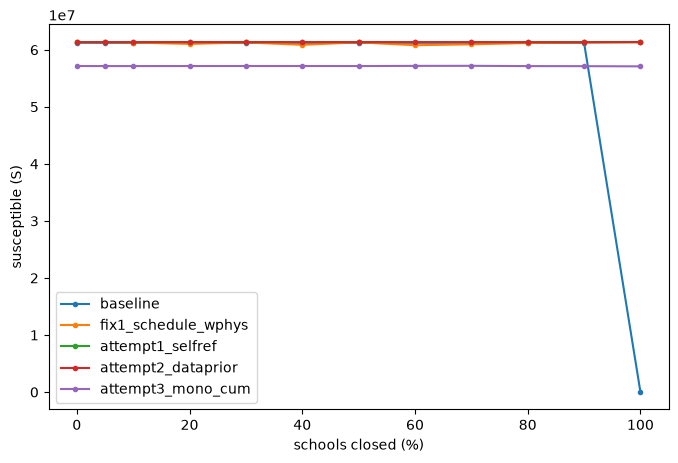

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, sw in sweeps.items():
    ax.plot([f * 100 for f, _, _ in sw], [s for _, s, _ in sw], "-o", ms=3, label=name)
ax.set_xlabel("schools closed (%)")
ax.set_ylabel("susceptible (S)")
ax.legend()
plt.show()

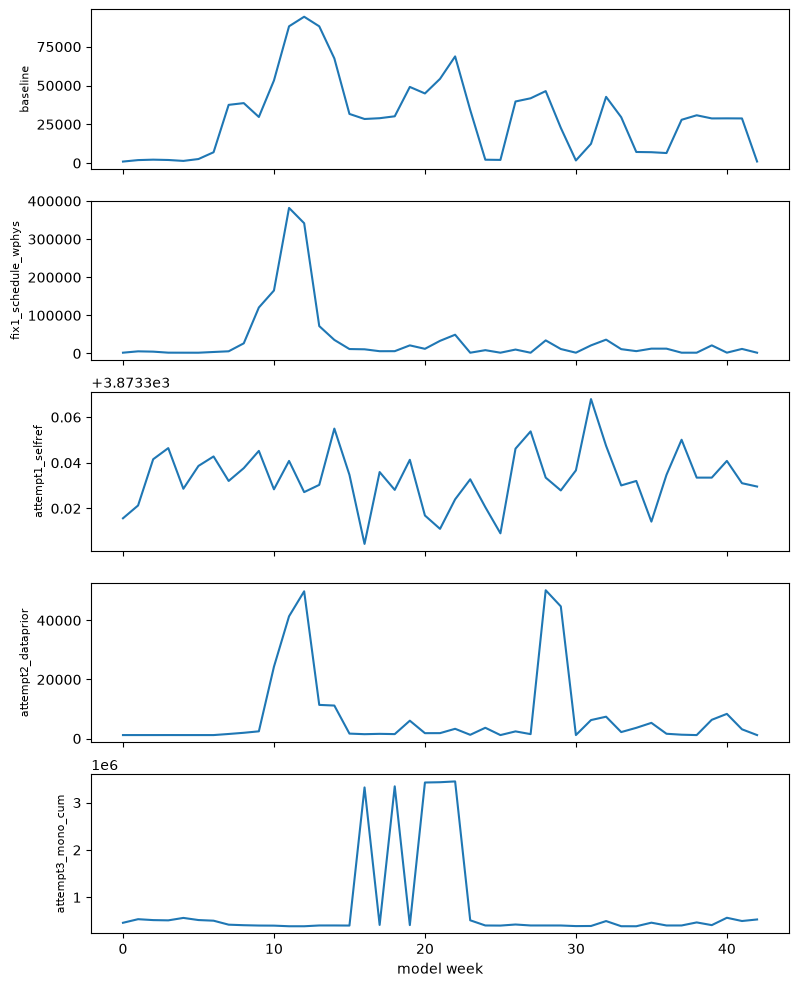

In [20]:
fig, axes = plt.subplots(len(seasons), 1, figsize=(9, 12), sharex=True)
for ax, (name, se) in zip(axes, seasons.items()):
    ax.plot([w for w, _, _ in se], [r for _, _, r in se])
    ax.set_ylabel(name, fontsize=8)
axes[-1].set_xlabel("model week")
plt.show()

In [21]:
def evaluate_pinn(source):
    trainer = source if isinstance(source, PINNTrainer) else load_net(source)
    sweep = closure_sweep(trainer)
    season_R = [r for _, _, r in full_season(trainer)]
    ww_R = [r for _, _, r in within_week(trainer, 20)]
    return {
        "R0": round(trainer.r0.item(), 4),
        "closure_range_0_90": round(s_range_0_90(sweep)),
        "season_R_monotonic": all(season_R[i + 1] >= season_R[i] - 1 for i in range(len(season_R) - 1)),
        "within_week_R_rising": ww_R[-1] > ww_R[0],
    }

In [22]:
evaluate_pinn(CKPT_FIX1)

{'R0': 1.7462,
 'closure_range_0_90': 550660,
 'season_R_monotonic': False,
 'within_week_R_rising': False}

In [23]:
KEVIN_FIX_CKPT = CKPT_ATTEMPT3_MONO_CUM
evaluate_pinn(KEVIN_FIX_CKPT)

{'R0': 0.7184,
 'closure_range_0_90': 58972,
 'season_R_monotonic': False,
 'within_week_R_rising': False}

In [24]:
{name: evaluate_pinn(ckpt) for name, ckpt in runs}

Rebuilding network to match checkpoint architecture (5x128, embed=8).


{'baseline': {'R0': 1.0127,
  'closure_range_0_90': 41260,
  'season_R_monotonic': False,
  'within_week_R_rising': False},
 'fix1_schedule_wphys': {'R0': 1.7462,
  'closure_range_0_90': 550660,
  'season_R_monotonic': False,
  'within_week_R_rising': False},
 'attempt1_selfref': {'R0': 1.6966,
  'closure_range_0_90': 16,
  'season_R_monotonic': True,
  'within_week_R_rising': True},
 'attempt2_dataprior': {'R0': 1.6817,
  'closure_range_0_90': 20880,
  'season_R_monotonic': False,
  'within_week_R_rising': True},
 'attempt3_mono_cum': {'R0': 0.7184,
  'closure_range_0_90': 58972,
  'season_R_monotonic': False,
  'within_week_R_rising': False}}

In [25]:
kevin_trainer = PINNTrainer(data, mcfg, TrainConfig(dropout_rate=0.1, device=DEVICE))
kevin_trainer.load_checkpoint(CKPT_FIX1)
evaluate_pinn(kevin_trainer)

{'R0': 1.7462,
 'closure_range_0_90': 550660,
 'season_R_monotonic': False,
 'within_week_R_rising': False}